In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [7]:
!pip install seaborn
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


In [4]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

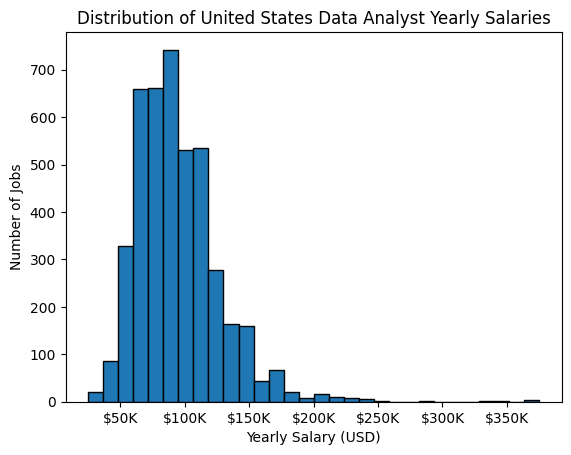

In [5]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()


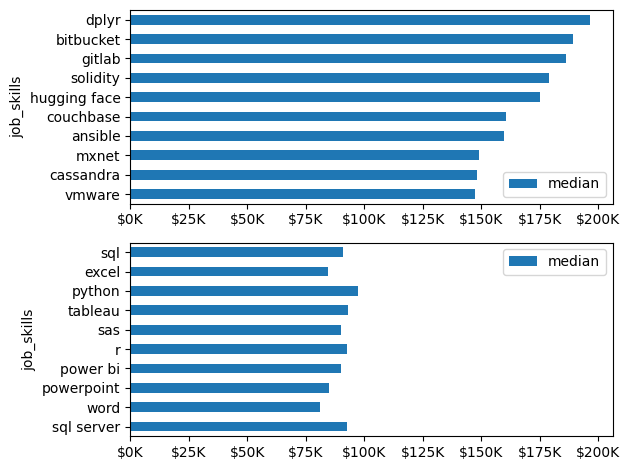

In [9]:
df_DA_US=df_DA_US.explode('job_skills')
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_top_pay = df_DA_US_group.sort_values(by='median',ascending=False).head(10)
df_DA_skills = df_DA_US_group.sort_values(by='count',ascending=False).head(10)
df_DA_skills
fig,ax = plt.subplots(2,1)

df_DA_top_pay.plot(kind='barh', y='median' ,ax=ax[0])
ax[0].invert_yaxis()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))

df_DA_skills[::-1].plot(kind='barh' ,y='median' ,ax=ax[1])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
fig.tight_layout()

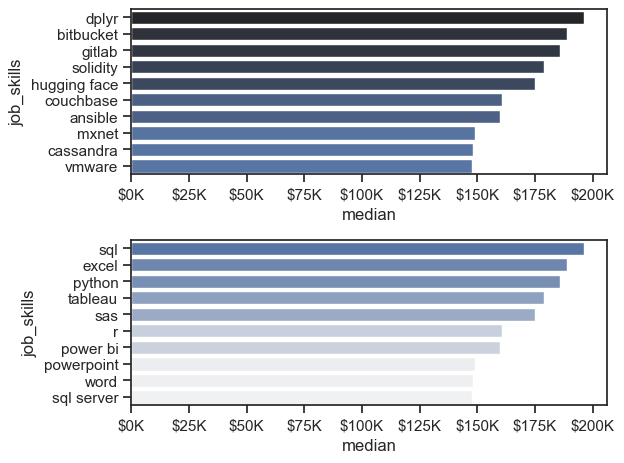

In [28]:
df_DA_US=df_DA_US.explode('job_skills')

df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_top_pay = df_DA_US_group.sort_values(by='median',ascending=False).head(10)
df_DA_skills = df_DA_US_group.sort_values(by='count',ascending=False).head(10)
df_DA_skills

sns.set_theme(style='ticks')
fig,ax = plt.subplots(2,1)

sns.barplot(data=df_DA_top_pay,x='median',y=df_DA_top_pay.index, ax=ax[0],hue='median' , palette= 'dark:b_r')
ax[0].legend().remove()       
#df_DA_top_pay.plot(kind='barh', y='median' ,ax=ax[0],legend=False)
            
#ax[0].invert_yaxis()
            
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_top_pay,x='median',y=df_DA_skills.index,ax=ax[1], hue='median', palette= 'light:b')            

ax[1].legend().remove()        

#df_DA_skills[::-1].plot(kind='barh' ,y='median' ,ax=ax[1],legend=False)

ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${int(x/1000)}K'))
            
#ax[1].set_xlim(ax[0].get_xlim())

fig.tight_layout()

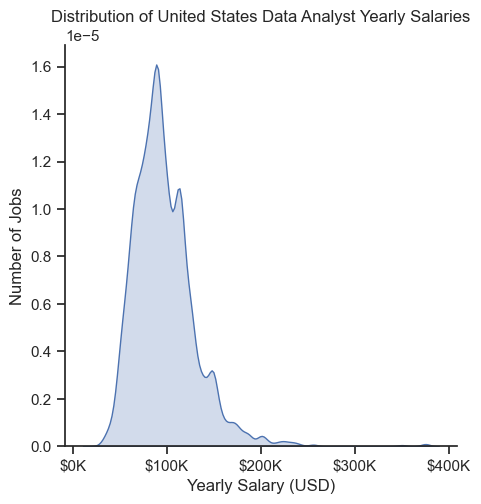

In [31]:
#df_DA_US['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')


sns.displot(df_DA_US['salary_year_avg'],kind='kde',fill=True)
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()


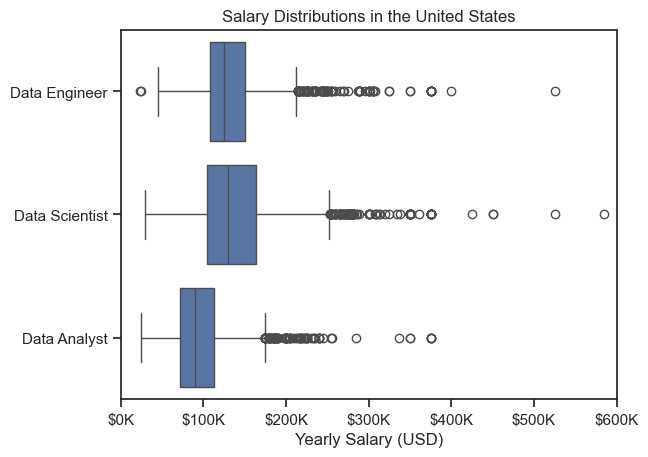

In [34]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# filter for the job titles and country
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

# list of salaries for each job title
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short')
sns.set_theme(style='ticks')

# this is all the same
plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()


In [ ]:
# Problem Statement:
# Create a Seaborn bar plot to visualize the top 5 companies with the highest median salary_year_avg
# for Data Scientist job postings in the United States.


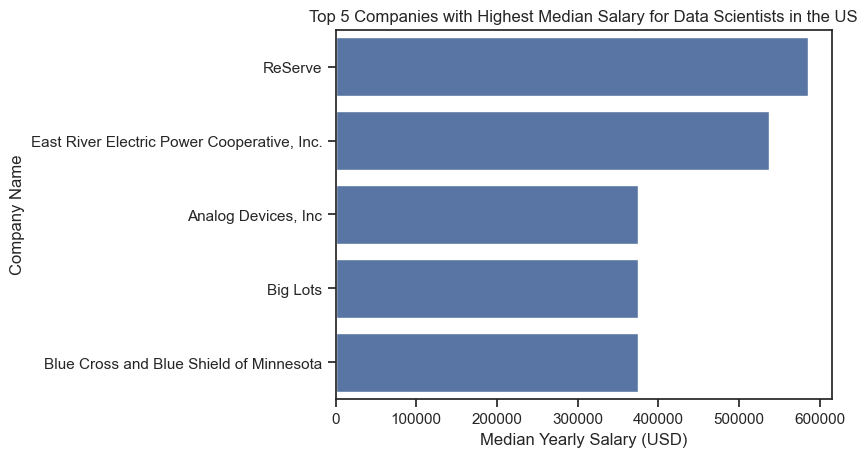

In [35]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg']).copy()
top_companies = df_DS_US.groupby('company_name')['salary_year_avg'].median().nlargest(5).reset_index()

sns.barplot(data=top_companies, x='salary_year_avg', y='company_name')
plt.title('Top 5 Companies with Highest Median Salary for Data Scientists in the US')
plt.xlabel('Median Yearly Salary (USD)')
plt.ylabel('Company Name')
plt.show()

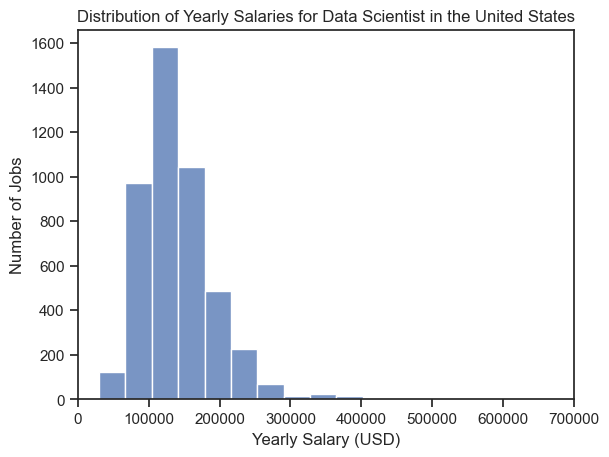

In [36]:
# Problem Statement:
# Create a histogram using Seaborn to visualize the distribution of average yearly salaries (use the salary_year_avg column) 
# for Data Scientist job postings in the United States:

# Filter the DataFrame to include only job postings in the United States and remove any entries with missing yearly salary values.
# Use 25 bins for the histogram and set the x-axis limit to 700,000.
# Set the title to 'Distribution of Yearly Salaries for Data Scientist in the United States' 
# and label the y-axis 'Number of Jobs' and x-axis 'Yearly Salary (USD)'.

us_ds_jobs = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Scientist')].copy()

# Drop NaN values from the 'salary_year_avg' column
us_ds_jobs = us_ds_jobs.dropna(subset=['salary_year_avg'])

# Plot histogram for yearly average salary
sns.histplot(us_ds_jobs['salary_year_avg'], bins=25, kde=False)
plt.title('Distribution of Yearly Salaries for Data Scientist in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
plt.xlim(0,700000)
plt.show()


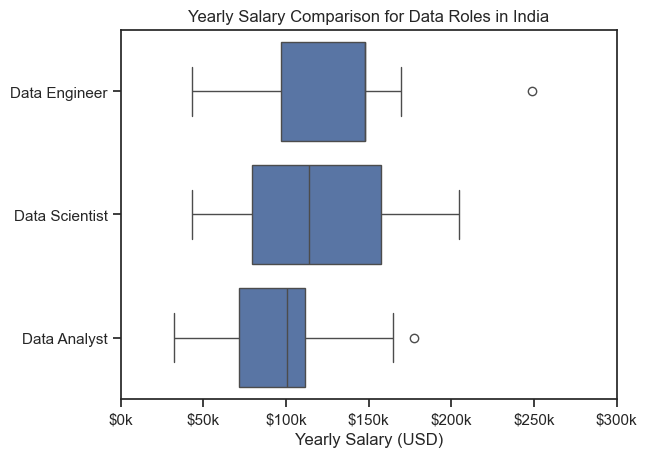

In [37]:
# create a box plot using Seaborn to compare the yearly salaries (use the salary_year_avg column) of Data Analyst, Data Engineer, 
# and Data Scientist job postings in India:

# Filter the DataFrame to include only job postings in India and remove any entries with missing yearly salary values.
# Set the x-axis limit to 300,000 and format it as $100k.
# Set the title to 'Yearly Salary Comparison for Data Roles in India' and label the x-axis as 'Yearly Salary (USD)'.
# Code Needed:
# job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# Filter for Data Analyst, Data Engineer, and Data Scientist job postings in India
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
india_jobs = df[(df['job_country'] == 'India') & (df['job_title_short'].isin(job_titles))]

# Drop NaN values from the 'salary_year_avg' column
india_jobs = india_jobs.dropna(subset=['salary_year_avg'])

# Plot box plot for yearly average salary
sns.boxplot(data=india_jobs, x='salary_year_avg', y='job_title_short')
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 300000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.show()

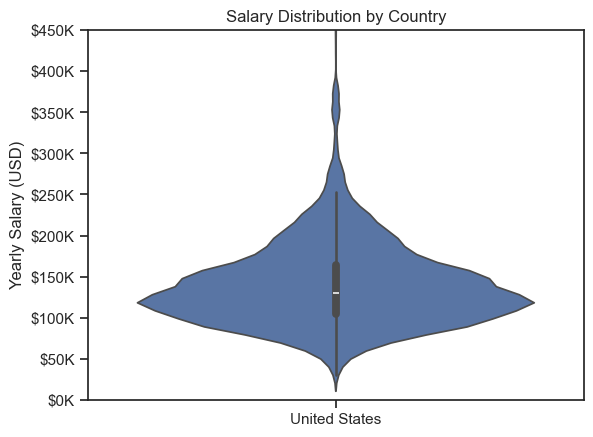

In [39]:
# Problem Statement:
# Create a violin plot using Seaborn to visualize the distribution of salary_year_avg for Data Scientist roles in the United States.
# Ensure the plot includes a title, axis labels, and custom formatting for the salary axis.
# Filter the DataFrame for Data Scientist job postings in the United States
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

# Plot chart
sns.violinplot(x='job_country', y='salary_year_avg', data=df_DS_US)
plt.title('Salary Distribution by Country')
plt.xlabel('')
plt.ylabel('Yearly Salary (USD)')
plt.ylim(0, 450000)  
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()